# ICPRAM 2026
## Facial Emotion Recognition: a comparative study with cross-corpus and multi-corpus training

This paper presents a systematic experimental study of FER generalization under cross-corpus and multi-corpus training. Rather than introducing a novel architecture, we focus on analyzing how different learning strategies and dataset combinations influence model robustness, efficiency, and failure modes across domains. 

We compare a lightweight convolutional baseline against a transformer-based FER model and a domain adaptation strategy, and we conduct ablation experiments to quantify the marginal utility of small datasets in large-scale training setups.

Even without changing seeds:
- GPU/MPS is not dterministic
- The real order of parallel operations changes
- Small numeric differences accumulate
- Networks with attention + softmax + AdamW amplify the differences

Result: slightly different runs, normally ±0.1–1%.

In [1]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices('GPU'))

import random
import numpy as np
import torch

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Almost deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 7
set_seed(SEED)

2.14.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import numpy as np
# built-in imports
import sys
import os
# src imports
module_path = os.path.abspath(os.path.join('..', '..')) 
sys.path.insert(0, module_path)
from src.data_loading import load_affectnet, load_ck, load_fer2013, load_rafbd, filter_emotions

affect = filter_emotions(load_affectnet()) 
ck = filter_emotions(load_ck())
ck['pixels'] = ck['pixels'].apply(lambda x: np.array([int(p) for p in x.split(" ")]).reshape(48,48))
fer = filter_emotions(load_fer2013())
fer['pixels'] = fer['pixels'].apply(lambda x: np.array([int(p) for p in x.split(" ")]).reshape(48,48))
raf = filter_emotions(load_rafbd())

/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: /Users/krazmic/.cache/kagglehub/datasets/mstjebashazida/affectnet/versions/1
Available folders: ['happy', 'Contempt', 'sad', 'fear', 'surprise', 'neutral', 'Anger', 'disgust']


100%|██████████| 8/8 [00:05<00:00,  1.51it/s]


Subfolders in the dataset: ['ckextended.csv']
Subfolders in the dataset: ['fer2013.csv']


100%|██████████| 3068/3068 [00:00<00:00, 5631.86it/s]


In [3]:
#print(ck.pixels.iloc[0])
#print(fer.pixels.iloc[0])
#print(raf.pixels.iloc[0])
#print(affect.pixels.iloc[0])

### Data Preprocessing

In [4]:
from transformers import MobileViTImageProcessor, MobileViTForImageClassification
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

LABEL_MAP = {
    "angry": 0,
    "disgust": 1,
    "fear": 2,
    "happy": 3,
    "sad": 4,
    "surprise": 5,
    "neutral": 6
}


class ImageDataset(Dataset):
    def __init__(self, df, feature_extractor):
        self.df = df.reset_index(drop=True)
        self.feature_extractor = feature_extractor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ---------
        # Load image
        # ---------
        if "pixels" in row and row["pixels"] is not None:
            img = row["pixels"]

            # FER / CK are grayscale → convert to RGB
            if img.ndim == 2:
                img = np.stack([img] * 3, axis=-1)

            image = Image.fromarray(img.astype(np.uint8))

        else:
            image = Image.open(row["filename"]).convert("RGB")

        label = LABEL_MAP[row["label"]]

        inputs = self.feature_extractor(
            images=image,
            return_tensors="pt"
        )

        return {
            "pixel_values": inputs["pixel_values"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }
    

def split_dataset_train_val_test(df, val_size=0.2, test_size=0.3, seed=SEED):
    train_val_df, test_df = train_test_split(df, test_size=test_size, random_state=seed, stratify=df['label'])
    train_df, val_df = train_test_split(train_val_df, test_size=val_size/(1 - test_size), random_state=seed, stratify=train_val_df['label'])
    return train_df, val_df, test_df


ck_train, ck_val, ck_test = split_dataset_train_val_test(ck)
raf_train, raf_val, raf_test = split_dataset_train_val_test(raf)
affect_train, affect_val, affect_test = split_dataset_train_val_test(affect)
fer_train, fer_val, fer_test = split_dataset_train_val_test(fer)

num_labels = len(LABEL_MAP)



In [7]:

from transformers import AdamW, get_cosine_schedule_with_warmup
from sklearn.metrics import accuracy_score, classification_report
from src.evaluation import plot_confusion_matrix #, plot_training_history
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("---- MPS DEVICE ----")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("---- CUDA DEVICE ----")
else:
    device = torch.device("cpu")
    print("---- CPU DEVICE ----")

---- MPS DEVICE ----


In [8]:
# load best model for evaluation
model = MobileViTForImageClassification.from_pretrained("mobilevit_affectnet_best")
feature_extractor = MobileViTImageProcessor.from_pretrained("mobilevit_affectnet_best")
model.to(device)

val_ds   = ImageDataset(affect_val, feature_extractor)
test_ds = ImageDataset(affect_test, feature_extractor)

val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

### AffectNet

Some weights of MobileViTForImageClassification were not initialized from the model checkpoint at apple/mobilevit-xx-small and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 320]) in the checkpoint and torch.Size([7, 320]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([7]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 001 | Train loss: 1.9390 | Val loss: 1.8877 | Train acc: 0.1740 | Val acc: 0.3085
Epoch 002 | Train loss: 1.6584 | Val loss: 1.2130 | Train acc: 0.4002 | Val acc: 0.4780
Epoch 003 | Train loss: 1.2058 | Val loss: 1.3165 | Train acc: 0.5159 | Val acc: 0.5431
Epoch 004 | Train loss: 1.0114 | Val loss: 0.8032 | Train acc: 0.5977 | Val acc: 0.5920
Epoch 005 | Train loss: 0.9156 | Val loss: 0.6978 | Train acc: 0.6371 | Val acc: 0.6200
Epoch 006 | Train loss: 0.8312 | Val loss: 1.4289 | Train acc: 0.6739 | Val acc: 0.6264
Epoch 007 | Train loss: 0.7644 | Val loss: 0.6230 | Train acc: 0.7055 | Val acc: 0.6200
Epoch 008 | Train loss: 0.6937 | Val loss: 0.6276 | Train acc: 0.7361 | Val acc: 0.5905
Epoch 009 | Train loss: 0.6433 | Val loss: 1.5061 | Train acc: 0.7622 | Val acc: 0.6476
Epoch 010 | Train loss: 0.5688 | Val loss: 0.2268 | Train acc: 0.7881 | Val acc: 0.5802
Epoch 011 | Train loss: 0.4959 | Val loss: 0.6315 | Train acc: 0.8137 | Val acc: 0.6419
Epoch 012 | Train loss: 0.4402 |

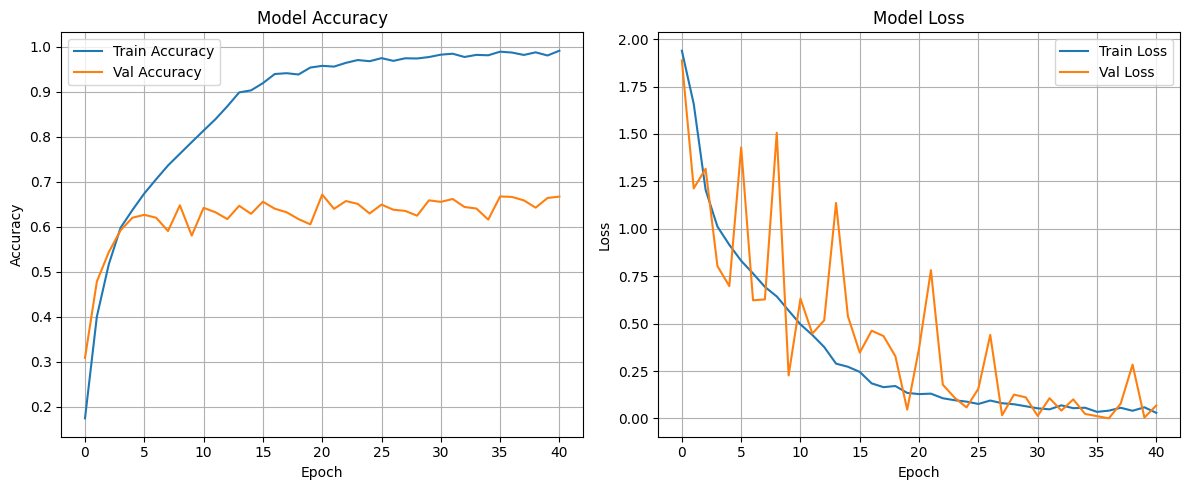

Validation accuracy on Affect Net: 0.6715
Test accuracy on Affect Net: 0.6671


In [9]:


feature_extractor = MobileViTImageProcessor.from_pretrained("apple/mobilevit-xx-small")
model = MobileViTForImageClassification.from_pretrained(
    "apple/mobilevit-xx-small",
    num_labels=num_labels,
    ignore_mismatched_sizes=True
)

train_ds = ImageDataset(affect_train, feature_extractor)
val_ds   = ImageDataset(affect_val, feature_extractor)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

#for name, param in model.named_parameters():
#    if "classifier" not in name:
#        param.requires_grad = False



patience = 20
num_epochs = 100 # 10
num_training_steps = num_epochs * len(train_loader)


optimizer = AdamW(model.parameters(), lr=3e-4)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps
)



model.to(device)

best_val_acc = 0.0
patience_counter = 0

history = {
            "loss": [],
            "val_loss": [],
            "accuracy": [],
            "val_accuracy": []
        }

for epoch in range(num_epochs):
    # -----------------
    # Train
    # -----------------
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0


    for batch in train_loader:
        optimizer.zero_grad()

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = correct / total


    # -----------------
    # Validation
    # -----------------
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(pixel_values=pixel_values)
            preds = torch.argmax(outputs.logits, dim=1)

            #loss = outputs.loss
            val_loss += loss.item()    
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    val_acc = accuracy_score(y_true, y_pred)
    val_loss /= len(val_loader)

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | " 
        f"Train acc: {train_acc:.4f} | " 
        f"Val acc: {val_acc:.4f}"
    )


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        model.save_pretrained("mobilevit_affectnet_best")
        feature_extractor.save_pretrained("mobilevit_affectnet_best")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break


plot_training_history(history)

# load best model for evaluation
model = MobileViTForImageClassification.from_pretrained("mobilevit_affectnet_best")
feature_extractor = MobileViTImageProcessor.from_pretrained("mobilevit_affectnet_best")
model.to(device)

val_ds   = ImageDataset(affect_val, feature_extractor)
test_ds = ImageDataset(affect_test, feature_extractor)

val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in val_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on Affect Net: {acc:.4f}")

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy on Affect Net: {acc:.4f}")



Validation accuracy on RAF-DB test: 0.1542


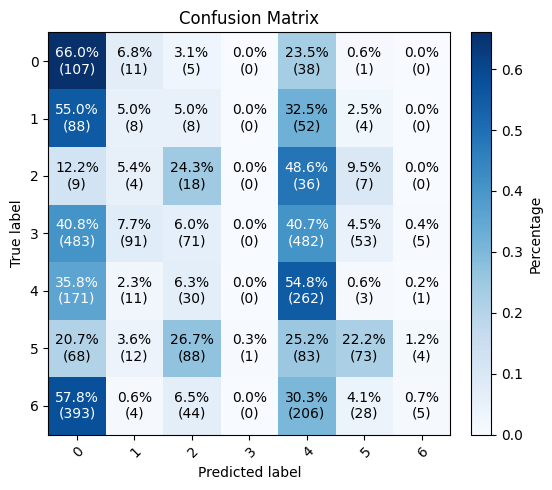

In [10]:
test_ds = ImageDataset(raf, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on RAF-DB test: {acc:.4f}")

plot_confusion_matrix(y_true, y_pred)

Validation accuracy on CK test: 0.1231


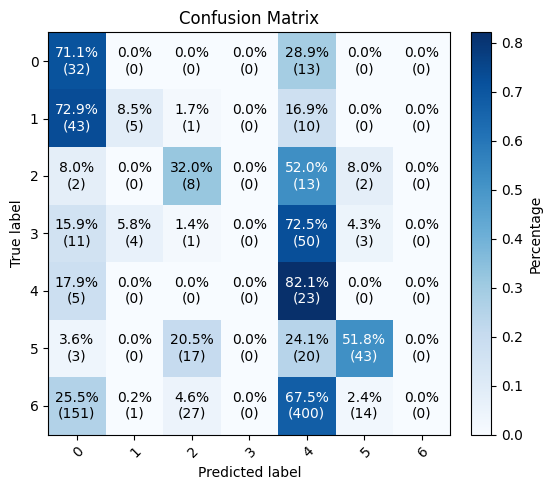

In [11]:
test_ds = ImageDataset(ck, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on CK test: {acc:.4f}")

plot_confusion_matrix(y_true, y_pred)

Validation accuracy on FER2013 test: 0.2120


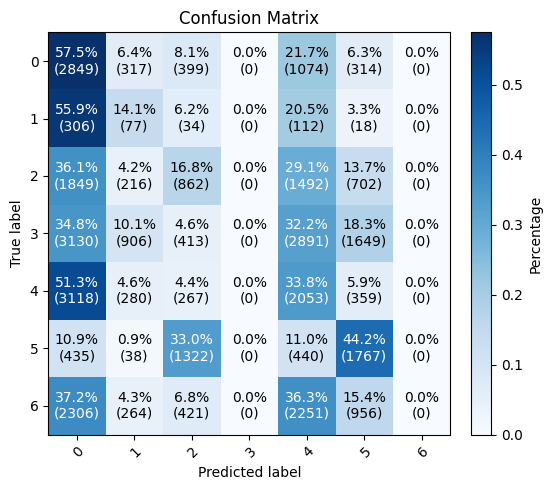

In [12]:
test_ds = ImageDataset(fer, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on FER2013 test: {acc:.4f}")

plot_confusion_matrix(y_true, y_pred)

## UMAP

In [ ]:

import numpy as np
import torch
import torch.nn.functional as F


def extract_embeddings(model, dataloader, device):
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for batch in dataloader:
            pixel_values = batch["pixel_values"].to(device)
            batch_labels = batch["labels"].cpu().numpy()

            outputs = model(
                pixel_values=pixel_values,
                output_hidden_states=True
            )

            # Last hidden state: [B, C, H, W]
            feats = outputs.hidden_states[-1]

            # Global Average Pooling
            feats = F.adaptive_avg_pool2d(feats, 1).squeeze(-1).squeeze(-1)

            embeddings.append(feats.cpu().numpy())
            labels.extend(batch_labels)

    embeddings = np.concatenate(embeddings, axis=0)
    labels = np.array(labels)

    return embeddings, labels




outputs = model(pixel_values, output_hidden_states=True)
features = outputs.hidden_states[-1]

affect_ds = ImageDataset(affect_test, feature_extractor)
raf_ds    = ImageDataset(raf, feature_extractor)

affect_loader = DataLoader(affect_ds, batch_size=32, shuffle=False)
raf_loader    = DataLoader(raf_ds, batch_size=32, shuffle=False)

X_affect, y_affect = extract_embeddings(model, affect_loader, device)
X_raf, y_raf       = extract_embeddings(model, raf_loader, device)

X = np.vstack([X_affect, X_raf])
y = np.concatenate([y_affect, y_raf])

domain = np.array(
    ["AffectNet"] * len(X_affect) +
    ["RAF-DB"] * len(X_raf)
)



/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


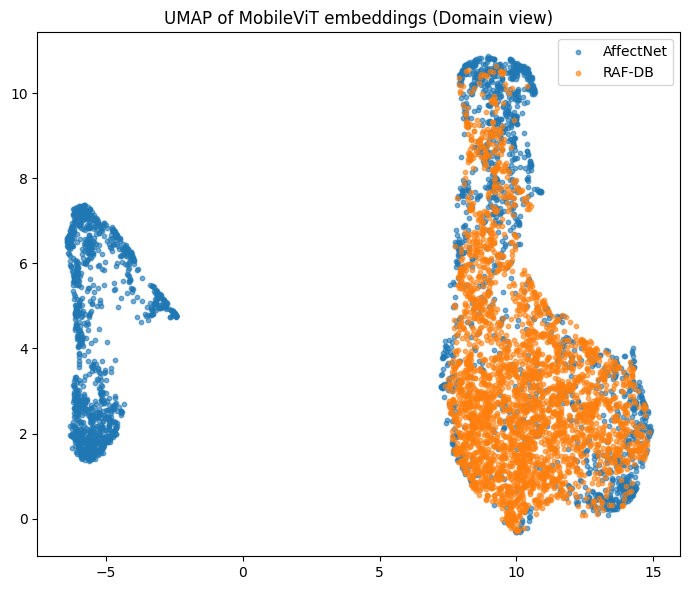

In [ ]:
import umap.umap_ as umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)

X_umap = reducer.fit_transform(X)

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
for d in ["AffectNet", "RAF-DB"]:
    idx = domain == d
    plt.scatter(
        X_umap[idx, 0],
        X_umap[idx, 1],
        s=10,
        alpha=0.6,
        label=d
    )

plt.legend()
plt.title("UMAP of MobileViT embeddings (Domain view)")
plt.tight_layout()
plt.show()


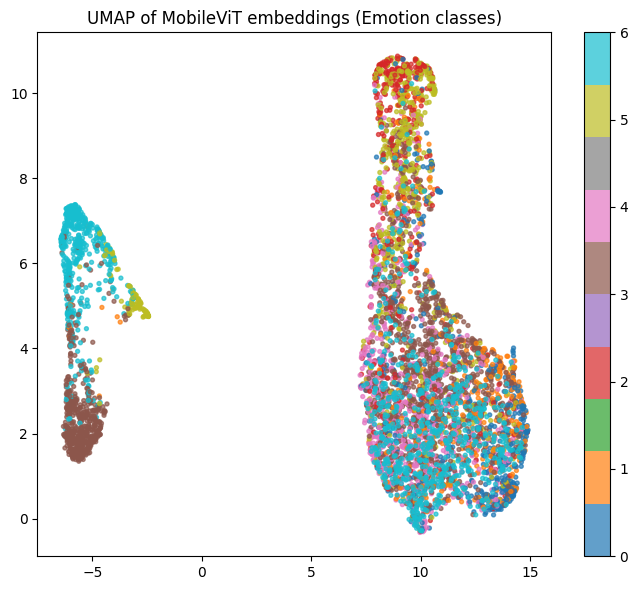

In [ ]:
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=y,
    cmap="tab10",
    s=8,
    alpha=0.7
)

plt.colorbar(scatter, ticks=range(7))
plt.title("UMAP of MobileViT embeddings (Emotion classes)")
plt.tight_layout()
plt.show()


## RAF-DB

Some weights of MobileViTForImageClassification were not initialized from the model checkpoint at apple/mobilevit-xx-small and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 320]) in the checkpoint and torch.Size([7, 320]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([7]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


---- MPS DEVICE ----
Epoch 001 | Train loss: 1.9450 | Val loss: 1.9373 | Train acc: 0.1689 | Val acc: 0.2264
Epoch 002 | Train loss: 1.9203 | Val loss: 1.9055 | Train acc: 0.2870 | Val acc: 0.3811
Epoch 003 | Train loss: 1.8532 | Val loss: 1.7930 | Train acc: 0.4475 | Val acc: 0.4593
Epoch 004 | Train loss: 1.6873 | Val loss: 1.5647 | Train acc: 0.5303 | Val acc: 0.4218
Epoch 005 | Train loss: 1.4332 | Val loss: 1.2808 | Train acc: 0.5832 | Val acc: 0.5603
Epoch 006 | Train loss: 1.1682 | Val loss: 1.1505 | Train acc: 0.6510 | Val acc: 0.5684
Epoch 007 | Train loss: 0.9806 | Val loss: 1.0342 | Train acc: 0.7025 | Val acc: 0.6156
Epoch 008 | Train loss: 0.8084 | Val loss: 0.7113 | Train acc: 0.7430 | Val acc: 0.5928
Epoch 009 | Train loss: 0.6459 | Val loss: 0.6042 | Train acc: 0.8115 | Val acc: 0.5293
Epoch 010 | Train loss: 0.6223 | Val loss: 0.9040 | Train acc: 0.8023 | Val acc: 0.5505
Epoch 011 | Train loss: 0.5073 | Val loss: 0.3094 | Train acc: 0.8376 | Val acc: 0.5635
Epoch 012 |

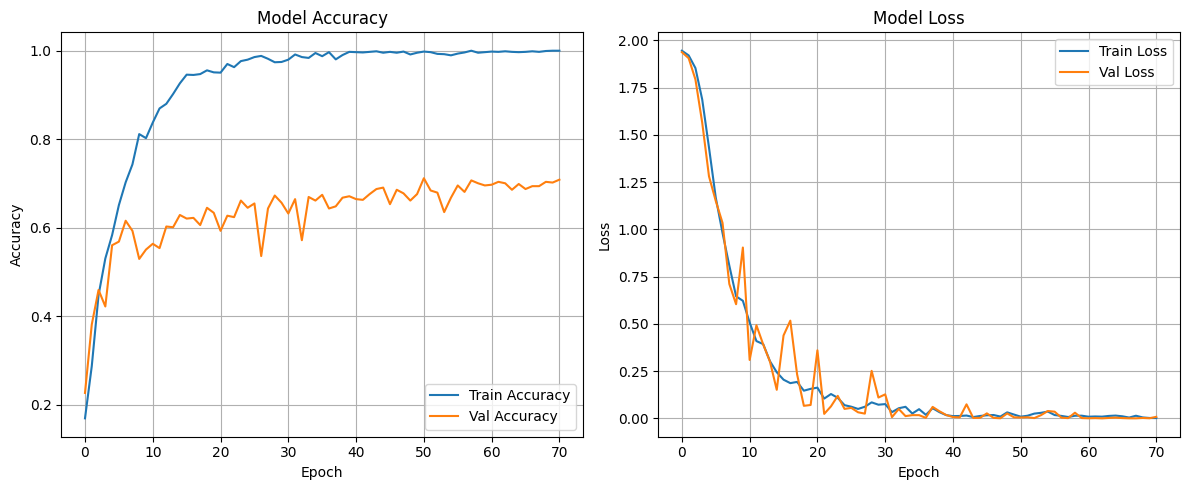

Validation accuracy on RAF-DBt: 0.7117
Test accuracy on RAF-DB: 0.6667


In [13]:


feature_extractor = MobileViTImageProcessor.from_pretrained("apple/mobilevit-xx-small")
model = MobileViTForImageClassification.from_pretrained(
    "apple/mobilevit-xx-small",
    num_labels=num_labels,
    ignore_mismatched_sizes=True
)

train_ds = ImageDataset(raf_train, feature_extractor)
val_ds   = ImageDataset(raf_val, feature_extractor)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

#for name, param in model.named_parameters():
#    if "classifier" not in name:
#        param.requires_grad = False



patience = 20
num_epochs = 100 # 10
num_training_steps = num_epochs * len(train_loader)


optimizer = AdamW(model.parameters(), lr=3e-4)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps
)


if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("---- MPS DEVICE ----")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("---- CUDA DEVICE ----")
else:
    device = torch.device("cpu")
    print("---- CPU DEVICE ----")

model.to(device)

best_val_acc = 0.0
patience_counter = 0

history = {
            "loss": [],
            "val_loss": [],
            "accuracy": [],
            "val_accuracy": []
        }

for epoch in range(num_epochs):
    # -----------------
    # Train
    # -----------------
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0


    for batch in train_loader:
        optimizer.zero_grad()

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = correct / total


    # -----------------
    # Validation
    # -----------------
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(pixel_values=pixel_values)
            preds = torch.argmax(outputs.logits, dim=1)

            #loss = outputs.loss
            val_loss += loss.item()    
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    val_acc = accuracy_score(y_true, y_pred)
    val_loss /= len(val_loader)

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | " 
        f"Train acc: {train_acc:.4f} | " 
        f"Val acc: {val_acc:.4f}"
    )


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        model.save_pretrained("mobilevit_rafdb_best")
        feature_extractor.save_pretrained("mobilevit_rafdb_best")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break


plot_training_history(history)

# load best model for evaluation
model = MobileViTForImageClassification.from_pretrained("mobilevit_rafdb_best")
feature_extractor = MobileViTImageProcessor.from_pretrained("mobilevit_rafdb_best")
model.to(device)


val_ds   = ImageDataset(raf_val, feature_extractor)
test_ds = ImageDataset(raf_test, feature_extractor)

val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in val_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on RAF-DBt: {acc:.4f}")

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy on RAF-DB: {acc:.4f}")

 

Validation accuracy on CK test: 0.5255


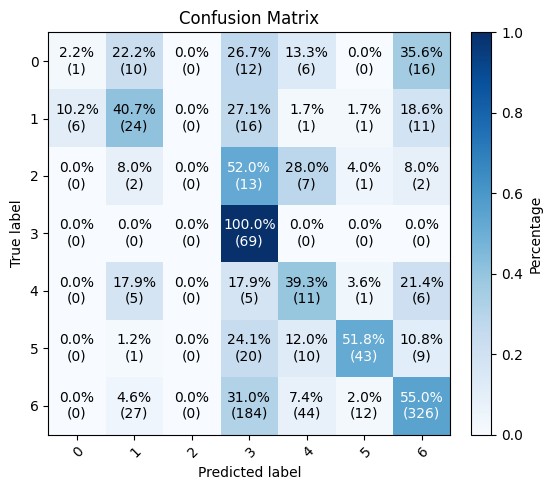

In [14]:
test_ds = ImageDataset(ck, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on CK test: {acc:.4f}")
plot_confusion_matrix(y_true, y_pred)

Validation accuracy on FER2013 test: 0.3625


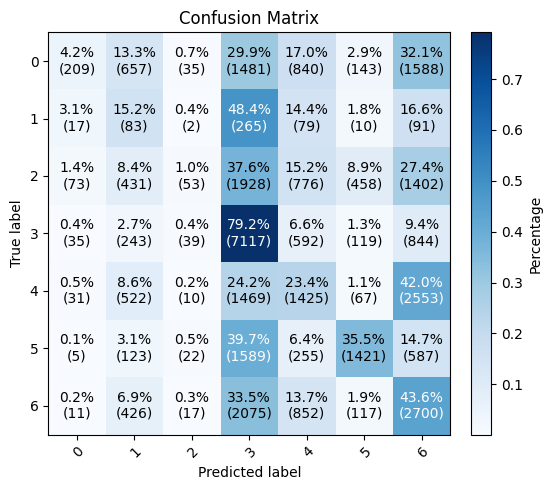

In [15]:
test_ds = ImageDataset(fer, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on FER2013 test: {acc:.4f}")
plot_confusion_matrix(y_true, y_pred)

Validation accuracy on AffectNet test: 0.1973


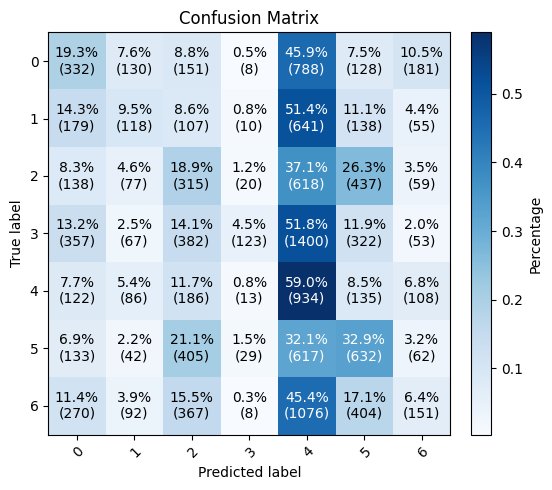

In [16]:
test_ds = ImageDataset(affect, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on AffectNet test: {acc:.4f}")
plot_confusion_matrix(y_true, y_pred)

### CK+

Some weights of MobileViTForImageClassification were not initialized from the model checkpoint at apple/mobilevit-xx-small and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 320]) in the checkpoint and torch.Size([7, 320]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([7]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


---- MPS DEVICE ----
Epoch 001 | Train loss: 1.9498 | Val loss: 1.9110 | Train acc: 0.1733 | Val acc: 0.3204
Epoch 002 | Train loss: 1.9385 | Val loss: 1.9450 | Train acc: 0.2356 | Val acc: 0.4199
Epoch 003 | Train loss: 1.9082 | Val loss: 1.8555 | Train acc: 0.3333 | Val acc: 0.5470
Epoch 004 | Train loss: 1.8736 | Val loss: 1.8806 | Train acc: 0.5044 | Val acc: 0.6188
Epoch 005 | Train loss: 1.8147 | Val loss: 1.8593 | Train acc: 0.6600 | Val acc: 0.6630
Epoch 006 | Train loss: 1.6827 | Val loss: 1.6992 | Train acc: 0.7644 | Val acc: 0.6243
Epoch 007 | Train loss: 1.4975 | Val loss: 1.9740 | Train acc: 0.7689 | Val acc: 0.7293
Epoch 008 | Train loss: 1.1351 | Val loss: 1.0826 | Train acc: 0.8489 | Val acc: 0.7790
Epoch 009 | Train loss: 0.8491 | Val loss: 0.8619 | Train acc: 0.8644 | Val acc: 0.7569
Epoch 010 | Train loss: 0.5919 | Val loss: 1.0948 | Train acc: 0.8978 | Val acc: 0.7182
Epoch 011 | Train loss: 0.5361 | Val loss: 1.0481 | Train acc: 0.9000 | Val acc: 0.8066
Epoch 012 |

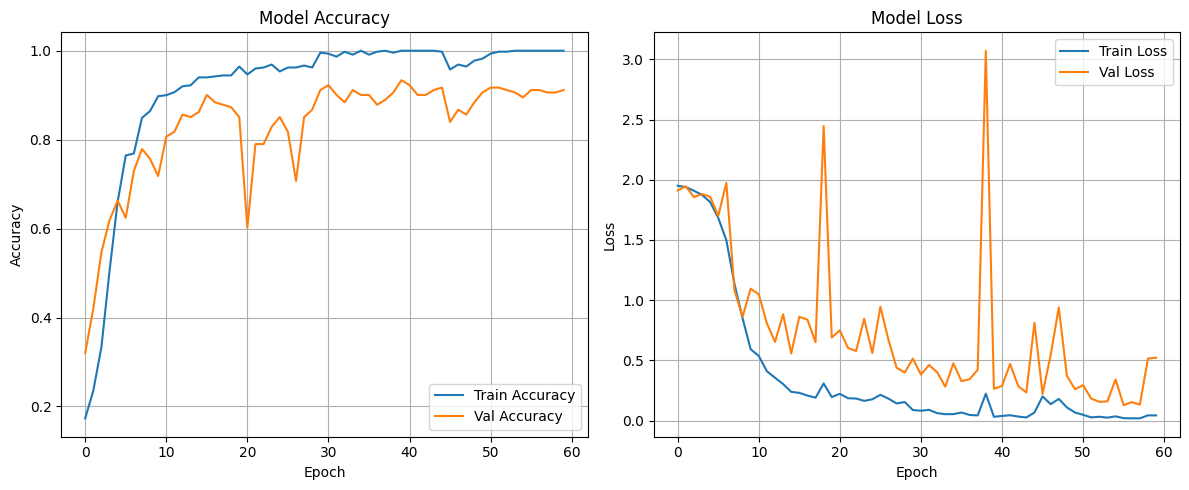

Validation accuracy on CK: 0.9337
Test accuracy on CK: 0.9299


In [17]:


feature_extractor = MobileViTImageProcessor.from_pretrained("apple/mobilevit-xx-small")
model = MobileViTForImageClassification.from_pretrained(
    "apple/mobilevit-xx-small",
    num_labels=num_labels,
    ignore_mismatched_sizes=True
)

train_ds = ImageDataset(ck_train, feature_extractor)
val_ds   = ImageDataset(ck_val, feature_extractor)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

#for name, param in model.named_parameters():
#    if "classifier" not in name:
#        param.requires_grad = False



patience = 20
num_epochs = 100 # 10
num_training_steps = num_epochs * len(train_loader)


optimizer = AdamW(model.parameters(), lr=3e-4)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps
)


if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("---- MPS DEVICE ----")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("---- CUDA DEVICE ----")
else:
    device = torch.device("cpu")
    print("---- CPU DEVICE ----")

model.to(device)

best_val_acc = 0.0
patience_counter = 0

history = {
            "loss": [],
            "val_loss": [],
            "accuracy": [],
            "val_accuracy": []
        }

for epoch in range(num_epochs):
    # -----------------
    # Train
    # -----------------
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0


    for batch in train_loader:
        optimizer.zero_grad()

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = correct / total


    # -----------------
    # Validation
    # -----------------
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(pixel_values=pixel_values)
            preds = torch.argmax(outputs.logits, dim=1)

            #loss = outputs.loss
            val_loss += loss.item()    
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    val_acc = accuracy_score(y_true, y_pred)
    val_loss /= len(val_loader)

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | " 
        f"Train acc: {train_acc:.4f} | " 
        f"Val acc: {val_acc:.4f}"
    )


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        model.save_pretrained("mobilevit_ck_best")
        feature_extractor.save_pretrained("mobilevit_ck_best")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break


plot_training_history(history)

# load best model for evaluation
model = MobileViTForImageClassification.from_pretrained("mobilevit_ck_best")
feature_extractor = MobileViTImageProcessor.from_pretrained("mobilevit_ck_best")
model.to(device)
 
val_ds   = ImageDataset(ck_val, feature_extractor)
test_ds = ImageDataset(ck_test, feature_extractor)

val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in val_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on CK: {acc:.4f}")

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy on CK: {acc:.4f}")

Validation accuracy on FER2013 test: 0.3465


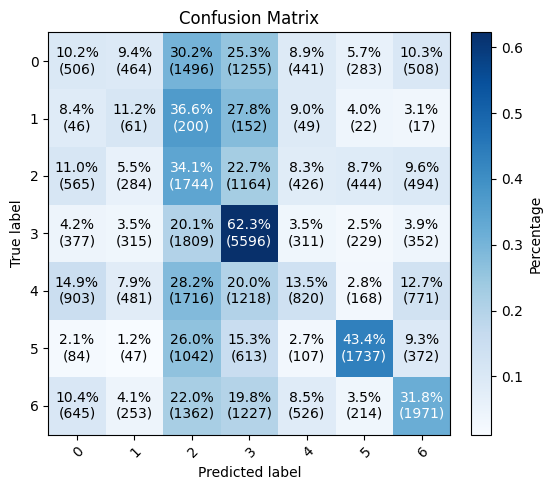

In [18]:
test_ds = ImageDataset(fer, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on FER2013 test: {acc:.4f}")
plot_confusion_matrix(y_true, y_pred)

Validation accuracy on RAF-DB test: 0.1001


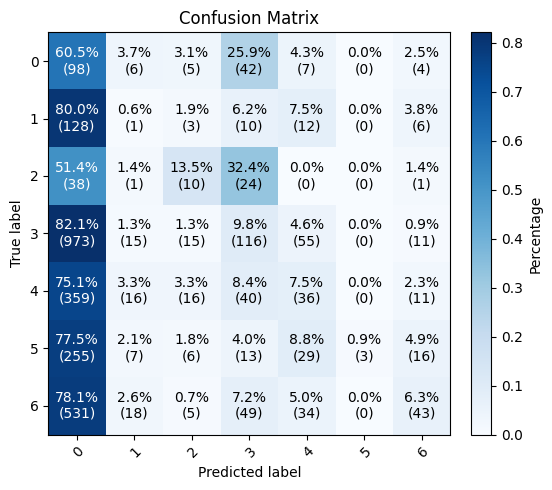

In [19]:
test_ds = ImageDataset(raf, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on RAF-DB test: {acc:.4f}")
plot_confusion_matrix(y_true, y_pred)

Validation accuracy on AffectNet test: 0.1630


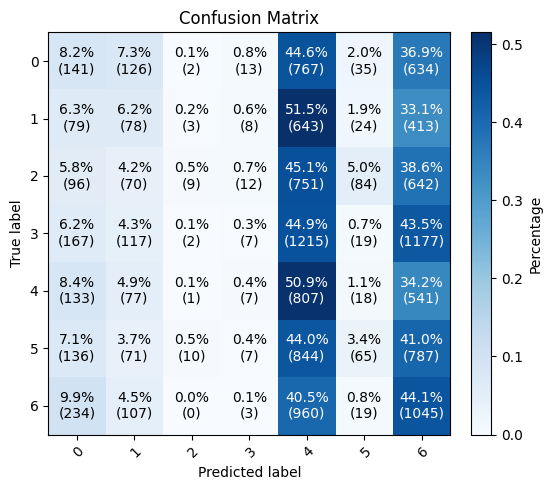

In [20]:
test_ds = ImageDataset(affect, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on AffectNet test: {acc:.4f}")
plot_confusion_matrix(y_true, y_pred)

### FER2013

Some weights of MobileViTForImageClassification were not initialized from the model checkpoint at apple/mobilevit-xx-small and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 320]) in the checkpoint and torch.Size([7, 320]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([7]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/krazmic/Documents/GitHub/Repos/EmoReA/.venv/lib/python3.11/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


---- MPS DEVICE ----
Epoch 001 | Train loss: 1.9117 | Val loss: 1.7571 | Train acc: 0.2416 | Val acc: 0.3785
Epoch 002 | Train loss: 1.5390 | Val loss: 1.3708 | Train acc: 0.4454 | Val acc: 0.4933
Epoch 003 | Train loss: 1.2802 | Val loss: 1.1051 | Train acc: 0.5263 | Val acc: 0.5352
Epoch 004 | Train loss: 1.1527 | Val loss: 1.1574 | Train acc: 0.5735 | Val acc: 0.5685
Epoch 005 | Train loss: 1.0690 | Val loss: 1.0966 | Train acc: 0.5985 | Val acc: 0.5851
Epoch 006 | Train loss: 0.9916 | Val loss: 0.7462 | Train acc: 0.6318 | Val acc: 0.5986
Epoch 007 | Train loss: 0.9377 | Val loss: 1.2489 | Train acc: 0.6524 | Val acc: 0.6052
Epoch 008 | Train loss: 0.8852 | Val loss: 0.9415 | Train acc: 0.6716 | Val acc: 0.5971
Epoch 009 | Train loss: 0.8336 | Val loss: 0.5666 | Train acc: 0.6921 | Val acc: 0.5862
Epoch 010 | Train loss: 0.7944 | Val loss: 0.9042 | Train acc: 0.7094 | Val acc: 0.5926
Epoch 011 | Train loss: 0.7394 | Val loss: 1.0845 | Train acc: 0.7271 | Val acc: 0.6089
Epoch 012 |

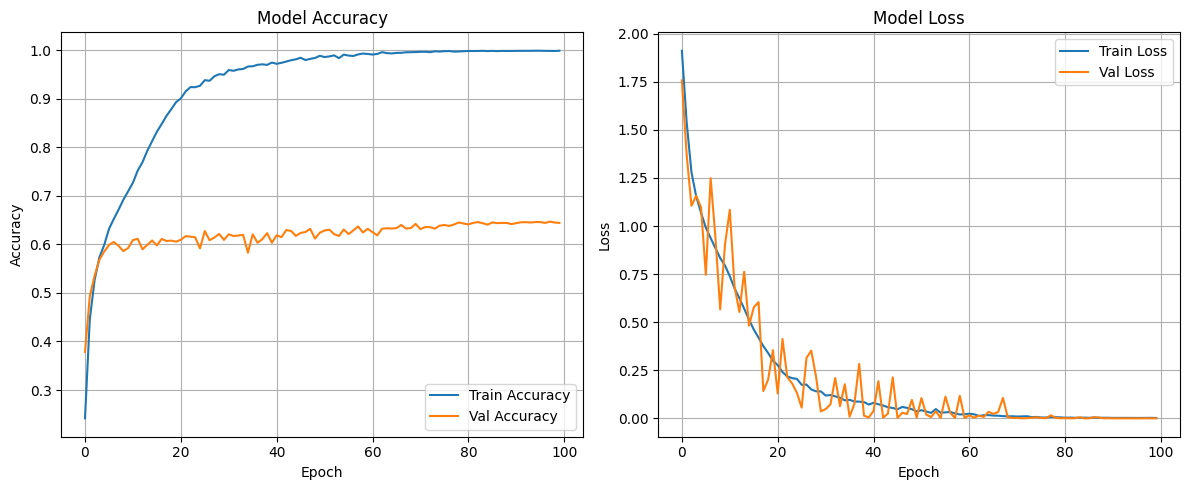

Validation accuracy on FER2013: 0.6470
Test accuracy on FER2013: 0.6507


In [21]:


feature_extractor = MobileViTImageProcessor.from_pretrained("apple/mobilevit-xx-small")
model = MobileViTForImageClassification.from_pretrained(
    "apple/mobilevit-xx-small",
    num_labels=num_labels,
    ignore_mismatched_sizes=True
)

train_ds = ImageDataset(fer_train, feature_extractor)
val_ds   = ImageDataset(fer_val, feature_extractor)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

#for name, param in model.named_parameters():
#    if "classifier" not in name:
#        param.requires_grad = False



patience = 20
num_epochs = 100 # 10
num_training_steps = num_epochs * len(train_loader)


optimizer = AdamW(model.parameters(), lr=3e-4)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps
)


if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("---- MPS DEVICE ----")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("---- CUDA DEVICE ----")
else:
    device = torch.device("cpu")
    print("---- CPU DEVICE ----")

model.to(device)

best_val_acc = 0.0
patience_counter = 0

history = {
            "loss": [],
            "val_loss": [],
            "accuracy": [],
            "val_accuracy": []
        }

for epoch in range(num_epochs):
    # -----------------
    # Train
    # -----------------
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0


    for batch in train_loader:
        optimizer.zero_grad()

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = correct / total


    # -----------------
    # Validation
    # -----------------
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(pixel_values=pixel_values)
            preds = torch.argmax(outputs.logits, dim=1)

            #loss = outputs.loss
            val_loss += loss.item()    
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    val_acc = accuracy_score(y_true, y_pred)
    val_loss /= len(val_loader)

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | " 
        f"Train acc: {train_acc:.4f} | " 
        f"Val acc: {val_acc:.4f}"
    )


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        model.save_pretrained("mobilevit_fer_best")
        feature_extractor.save_pretrained("mobilevit_fer_best")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break


plot_training_history(history)

# load best model for evaluation
model = MobileViTForImageClassification.from_pretrained("mobilevit_fer_best")
feature_extractor = MobileViTImageProcessor.from_pretrained("mobilevit_fer_best")
model.to(device)
 
val_ds   = ImageDataset(fer_val, feature_extractor)
test_ds = ImageDataset(fer_test, feature_extractor)

val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in val_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on FER2013: {acc:.4f}")

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy on FER2013: {acc:.4f}")

Validation accuracy on FER2013: 0.6470
Test accuracy on FER2013: 0.6507
              precision    recall  f1-score   support

           0       0.55      0.57      0.56      1486
           1       0.70      0.49      0.58       164
           2       0.51      0.47      0.49      1536
           3       0.83      0.86      0.84      2697
           4       0.54      0.53      0.54      1823
           5       0.78      0.77      0.78      1201
           6       0.59      0.62      0.61      1860

    accuracy                           0.65     10767
   macro avg       0.64      0.62      0.63     10767
weighted avg       0.65      0.65      0.65     10767



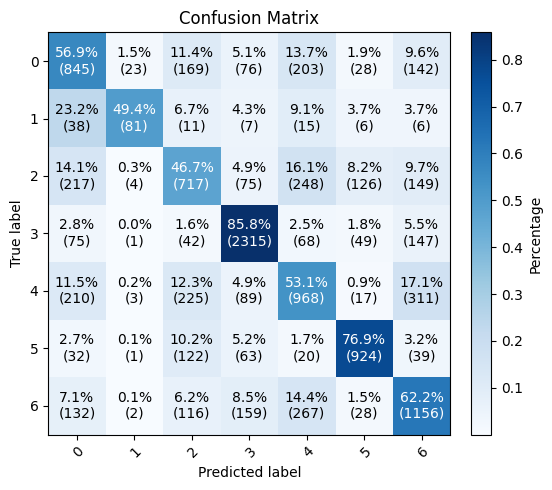

In [27]:
from src.evaluation import plot_confusion_matrix
from sklearn.metrics import classification_report
# load best model for evaluation
model = MobileViTForImageClassification.from_pretrained("mobilevit_fer_best")
feature_extractor = MobileViTImageProcessor.from_pretrained("mobilevit_fer_best")
model.to(device)
 
val_ds   = ImageDataset(fer_val, feature_extractor)
test_ds = ImageDataset(fer_test, feature_extractor)

val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in val_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on FER2013: {acc:.4f}")

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy on FER2013: {acc:.4f}")

print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred)


Validation accuracy on RAF-DB test: 0.4964


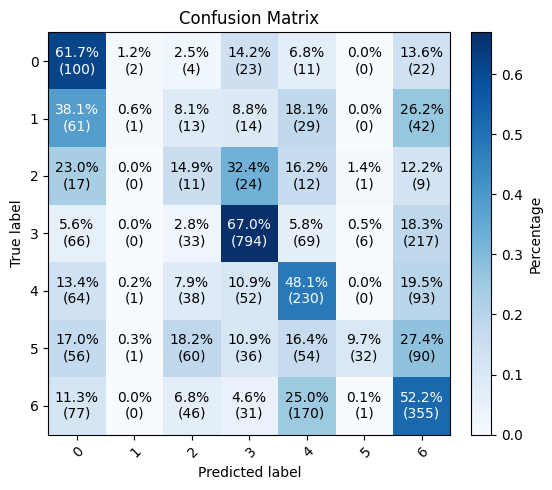

In [23]:
test_ds = ImageDataset(raf, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on RAF-DB test: {acc:.4f}")
plot_confusion_matrix(y_true, y_pred)

Validation accuracy on AffectNet test: 0.3599


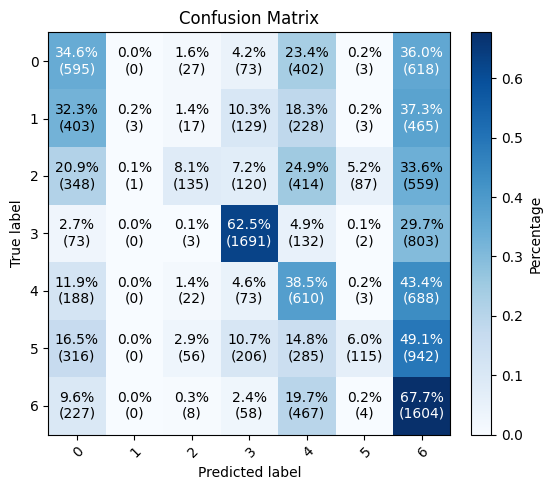

In [24]:
test_ds = ImageDataset(affect, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on AffectNet test: {acc:.4f}")
plot_confusion_matrix(y_true, y_pred)

Validation accuracy on CK test: 0.6973


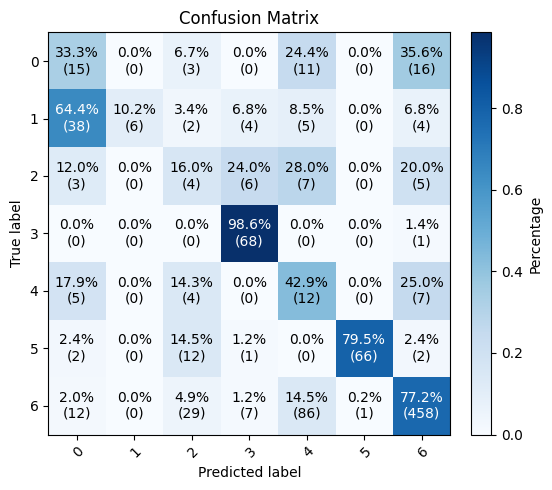

In [25]:
test_ds = ImageDataset(ck, feature_extractor)
test_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy on CK test: {acc:.4f}")
plot_confusion_matrix(y_true, y_pred)